Mutual Fund Analytics- Exploratory Data Analysis(EDA)

#OBJECTIVE:
This notebook performs Explorartory Data Analysis on Mutual Fund datasets to identify trends,investor behaviour, fund performance and market insights using Pyhton Visualization libraries.

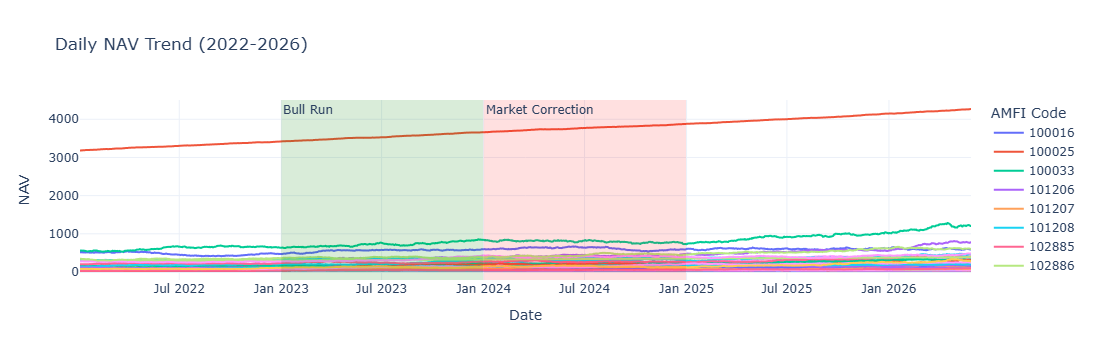

In [1]:
import pandas as pd
import plotly.express as px

df=pd.read_csv("data/processed/02_nav_history_clean.csv")
df["date"]= pd.to_datetime(df["date"])
fig= px.line(df, x="date", y="nav", color="amfi_code",
             title="Daily NAV Trend (2022-2026)")

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="Bull Run",
    annotation_position="top left"
)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="Market Correction",
    annotation_position="top left"
)
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    legend_title="AMFI Code"
)

fig.show()


1. Daily NAV Trend Analysis (2022-2026)
   Most funds show a gradual increase in NAV over time, indicating long-term appreciation.
   Not all schemes grow equally. One fund (around NAV 3200–4200) has a much higher NAV than the others, while many remain below 500. 

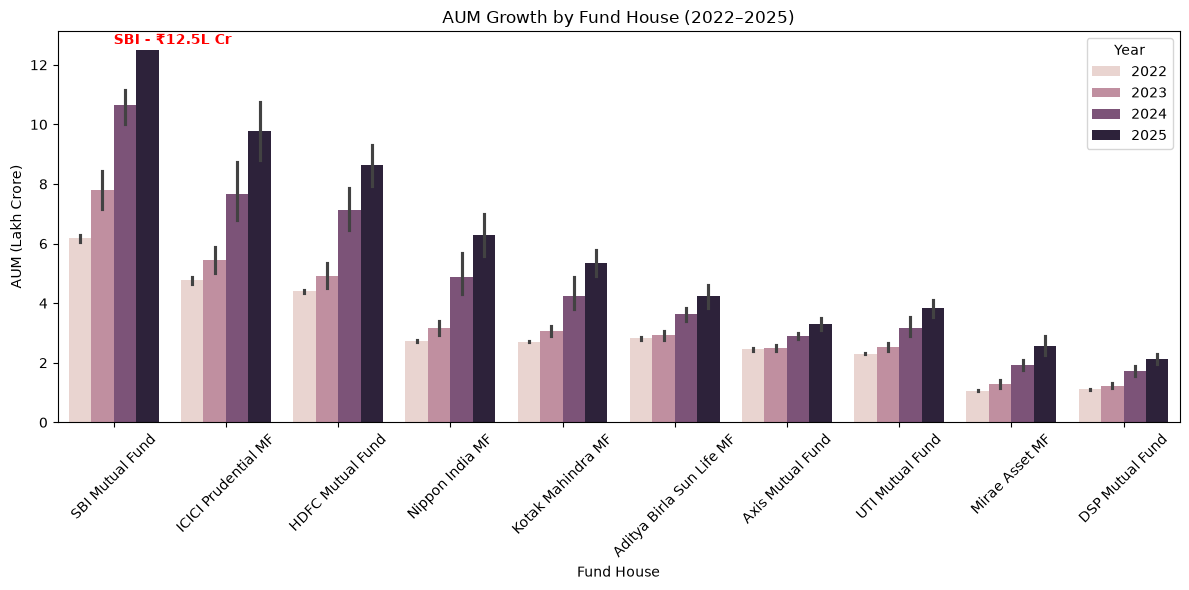

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("data/processed/03_aum_by_fund_house_clean.csv")
df["date"]=pd.to_datetime(df["date"])
df["year"]=df["date"].dt.year
df=df[df["year"].between(2022,2025)]
plt.figure(figsize=(12,6))
ax= sns.barplot(
    data=df,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)
sbi= df[df["fund_house"]=="SBI Mutual Fund"]
if not sbi.empty:
    max_aum=sbi["aum_lakh_crore"].max()
    plt.text(
        0,
        max_aum +0.2,
        "SBI - ₹12.5L Cr",
        color="red",
        fontsize=10,
        fontweight="bold"
    )

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()

plt.show()


**Insight:** 
AUM increased consistently across all fund houses from 2022 to 2025, with SBI Mutual Fund maintaining the highest AUM and emerging as the market leader at approximately ₹12.5 lakh crore in 2025.*


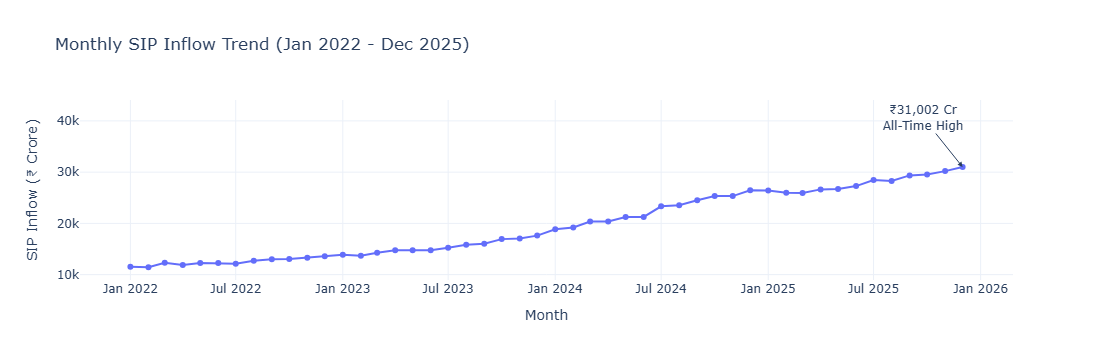

In [3]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("data/processed/04_monthly_sip_inflows_clean.csv")
# Convert month column to datetime
df["month"] = pd.to_datetime(df["month"])

fig = px.line(
    df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

highest = df.loc[df["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text="₹31,002 Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-50
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

**Insight:** 
Monthly SIP inflows showed a strong and consistent upward trend from 2022 to 2025, reaching an all-time high of **₹31,002 crore** in December 2025, reflecting growing investor participation.*


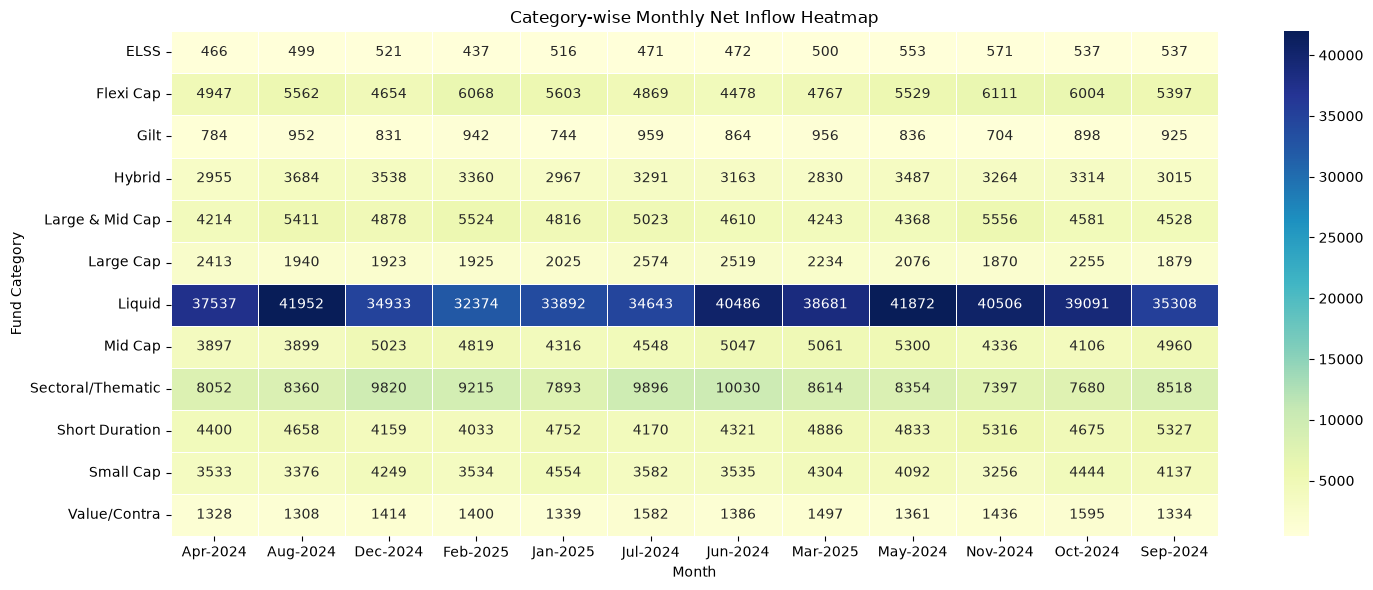

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/05_category_inflows_clean.csv")
df["month"] = pd.to_datetime(df["month"])
df["month"] = df["month"].dt.strftime("%b-%Y")

heatmap_data = df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

**Insight:** 
Liquid funds recorded the highest monthly net inflows across all categories, while Sectoral/Thematic and Flexi Cap funds also attracted strong investor inflows compared to other fund categories.*


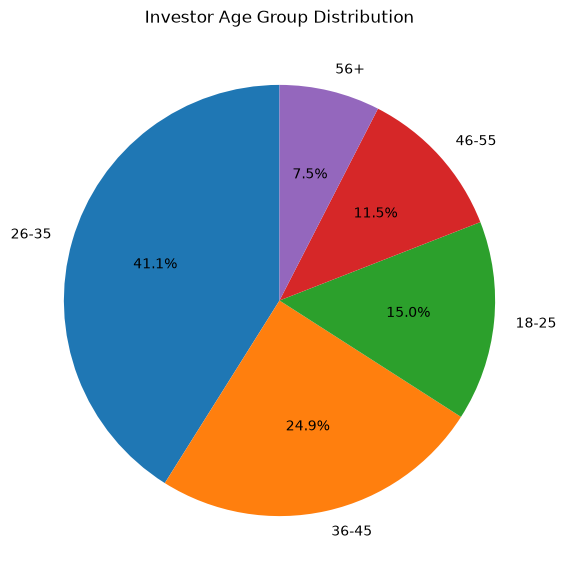

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/08_investor_transaction_clean.csv")

age_counts = df["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

**Insight**: 
The majority of investors belong to the 26–35 age group, suggesting that young professionals form a significant portion of the investor base.

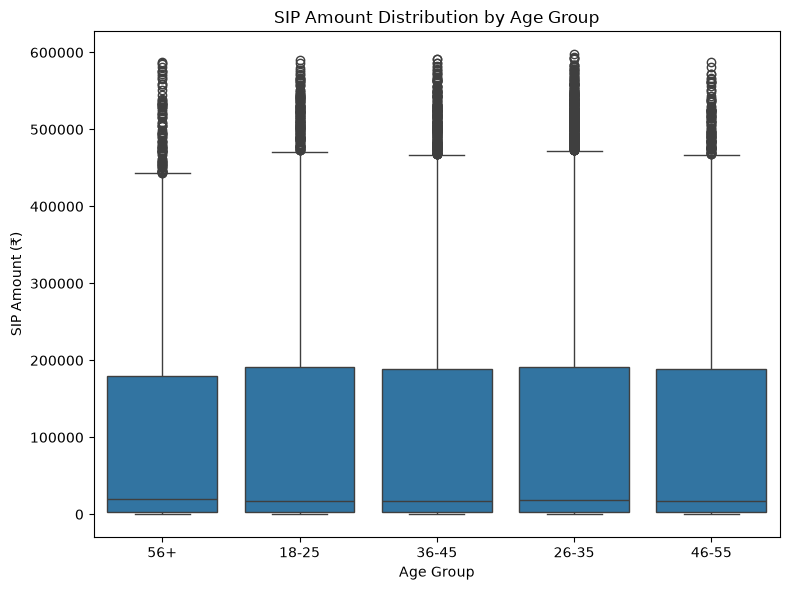

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/08_investor_transaction_clean.csv")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.show()

**Insight:** 
The SIP amount distribution is broadly similar across all age groups, with a few investors making significantly higher SIP investments, as indicated by the numerous outliers.*


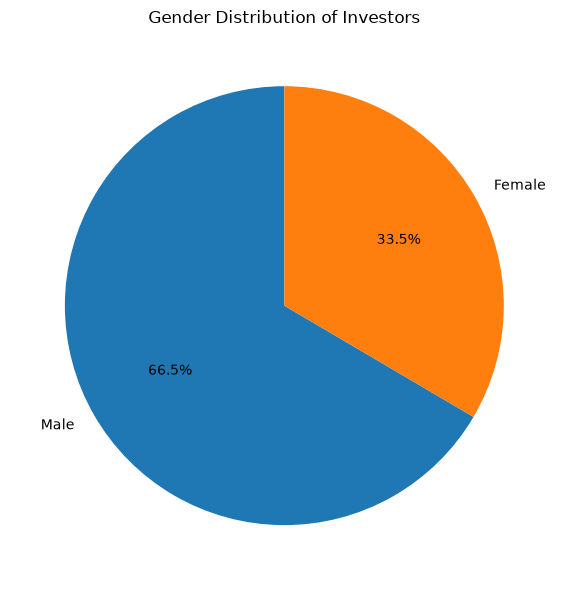

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/08_investor_transaction_clean.csv")

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Gender Distribution of Investors")
plt.tight_layout()
plt.show()

**Insight**:
The gender distribution chart shows the participation of male and female investors, providing insights into the demographic composition of the investor base. Male investors has more participation.

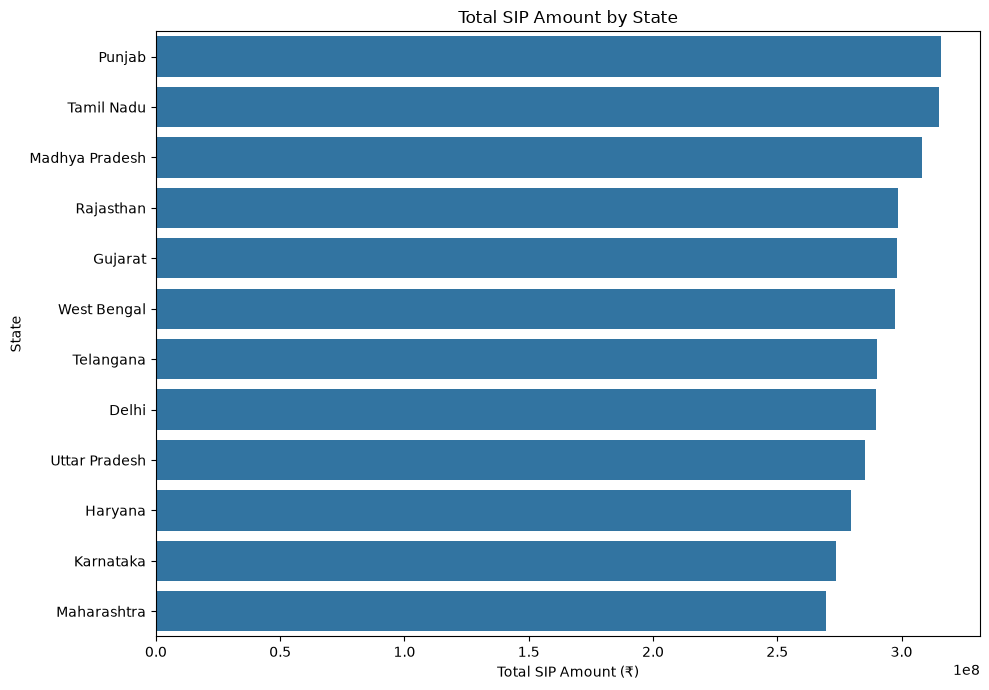

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/08_investor_transaction_clean.csv")

state_data = (
    df.groupby("state")["amount_inr"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10,7))
sns.barplot(
    data=state_data,
    x="amount_inr",
    y="state"
)
plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Insight:** 
Punjab recorded the highest total SIP amount among the selected states, while SIP investments remain relatively strong across all major states, indicating broad retail participation.*


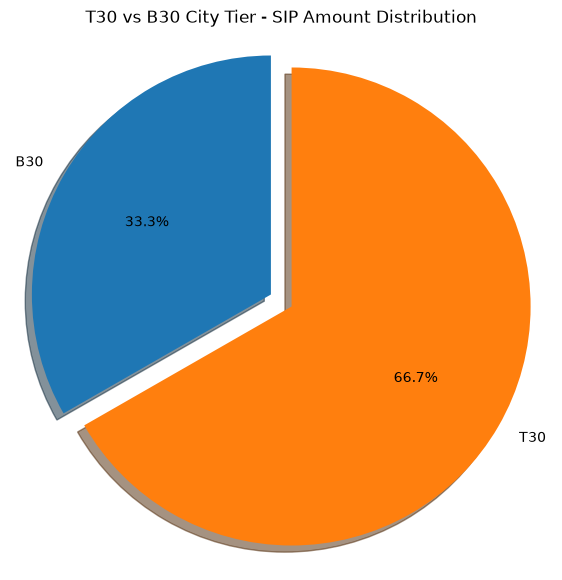

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/08_investor_transaction_clean.csv")
df = df[df["transaction_type"] == "Sip"]

tier_data = df.groupby("city_tier")["amount_inr"].sum()

plt.figure(figsize=(7,7))
plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0.05],
    shadow=True
)
plt.title("T30 vs B30 City Tier - SIP Amount Distribution")
plt.axis("equal")
plt.show()

**Insight**:
T30 City tier holds major SIP Amount Distribution

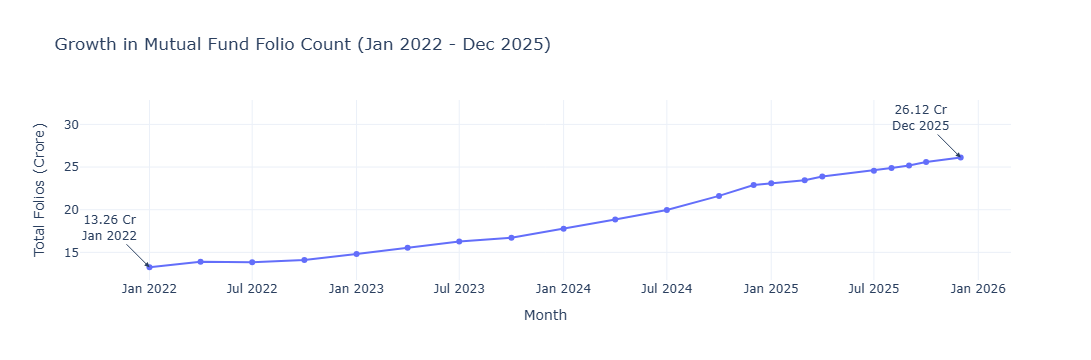

In [14]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("data/processed/06_industry_folio_count_clean.csv")

df["month"] = pd.to_datetime(df["month"])

fig = px.line(
    df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folio Count (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

fig.add_annotation(
    x=df.iloc[0]["month"],
    y=df.iloc[0]["total_folios_crore"],
    text="13.26 Cr<br>Jan 2022",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-40
)

fig.add_annotation(
    x=df.iloc[-1]["month"],
    y=df.iloc[-1]["total_folios_crore"],
    text="26.12 Cr<br>Dec 2025",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)
fig.show()

**Insight:** 
Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, demonstrating strong growth in investor participation.

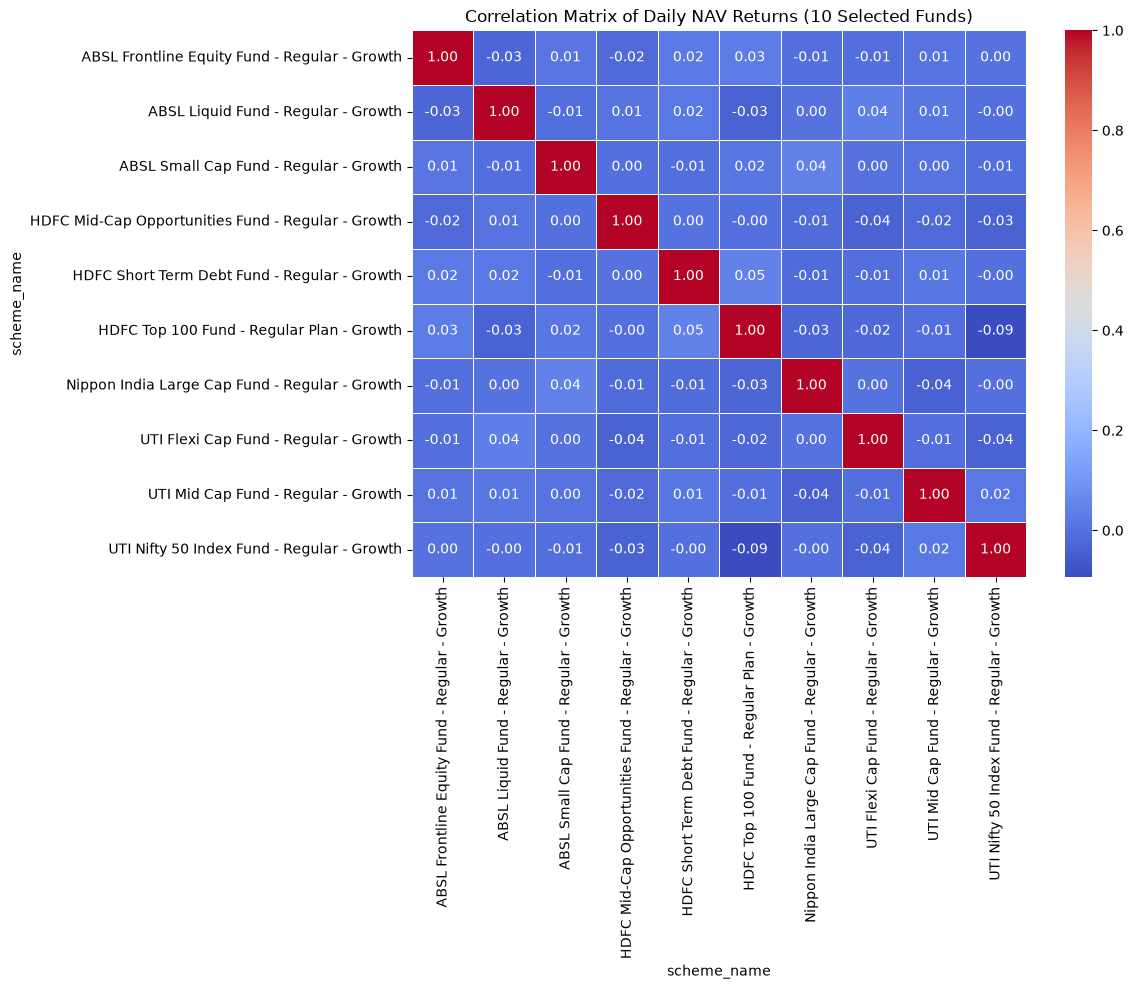

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
scheme = pd.read_csv("data/processed/01_fund_master_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.merge(
    scheme[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

selected = nav["scheme_name"].unique()[:10]
nav = nav[nav["scheme_name"].isin(selected)]

pivot = nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

returns = pivot.pct_change().dropna()
corr = returns.corr()
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)")
plt.tight_layout()
plt.show()

**Insight:**
The selected mutual funds show very weak correlations (mostly between -0.09 and 0.05), indicating that their daily NAV returns move largely independently and provide good diversification benefits.


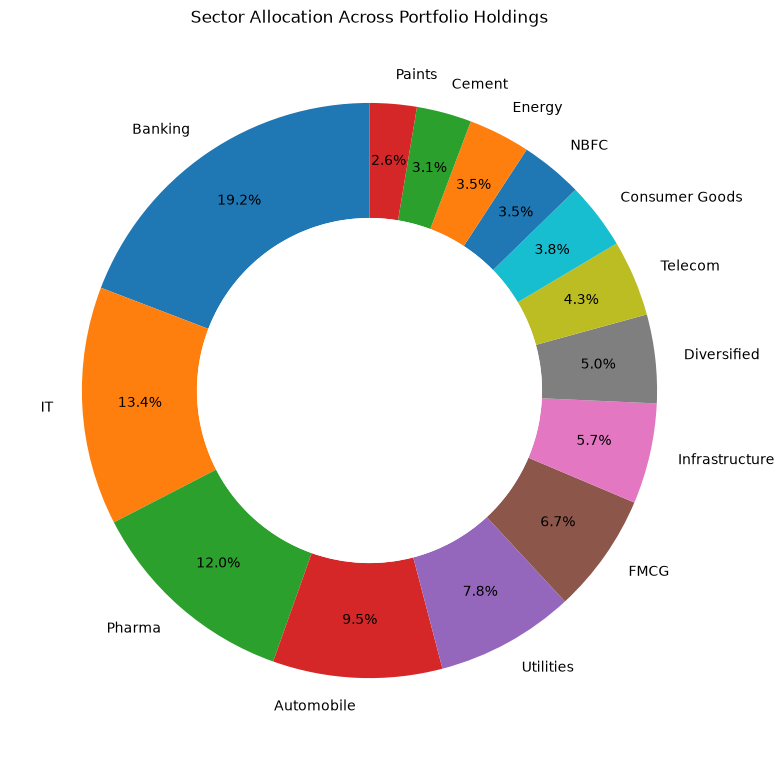

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/09_portfolio_holdings_clean.csv")
sector_weights = (
    df.groupby("sector")["weight_pct"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8, 8))
plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4},
    pctdistance=0.8
)

centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)
plt.title("Sector Allocation Across Portfolio Holdings")
plt.tight_layout()
plt.show()

**Insight:**
Banking (19.2%), IT (13.4%), and Pharma (12.0%) together account for nearly 45% of the portfolio, indicating that equity mutual funds are primarily concentrated in these three sectors.
